In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os

import matplotlib.pyplot as plt

%run -i wave_stats.py
%run -i parse_spc_file.py

parse_spc_file.py loaded.


### Assumes we have processed the bulk output
Load the bulk fluxes calcualted at the contour points

In [2]:
ds_tp = xr.load_dataset( "adcirc_bulk_fluxes_tp.nc" )

# # No longer necessary...have fixed the time in the .nc files.
# # Add 2 years to the time coordinate
# ds_tp = ds_tp.assign_coords(
#     time=pd.to_datetime(ds_tp['time'].values) + pd.DateOffset(years=2)
# )

ds_tp

<xarray.Dataset> Size: 12MB
Dimensions:             (time: 431, point: 425)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2024-09-23T12:15:00 ... 202...
  * point               (point) int64 3kB 0 1 2 3 4 5 ... 420 421 422 423 424
Data variables: (12/24)
    Hs_tp               (time, point) float32 733kB 0.0001161 0.0001428 ... 2.18
    TPS_tp              (time, point) float32 733kB 0.0 0.0 0.0 ... 8.843 8.855
    depth_p             (point) float32 2kB 31.53 31.37 30.82 ... 31.25 31.36
    lon_p               (point) float32 2kB -88.0 -87.98 ... -82.44 -82.44
    lat_p               (point) float32 2kB 29.96 29.96 29.96 ... 25.54 25.52
    x_p                 (point) float32 2kB -1.759e+05 -1.739e+05 ... 3.557e+05
    ...                  ...
    Eflux_mag_tp        (time, point) float32 733kB 0.0 0.0 0.0 ... 47.46 47.31
    Eflux_mag_wrms_tp   (time, point) float32 733kB 0.0 0.0 ... 0.2503 0.1591
    EfluxS_mag_tp       (time, point) float32 733kB 0.0 0.0 0.0 ... 1.888 1.278
    EfluxS_x_tp         (time, point) float32 733kB 0.0 0.0 0.0 ... 1.868 1.266
    EfluxS_y_tp         (time, point) float32 733kB 0.0 0.0 ... 0.2754 0.1735
    EfluxS_mag_wrms_tp  (time, point) float32 733kB 0.0 0.0 ... 0.3573 0.2778
Attributes:
    title:        Fluxes from bulk parameters at contour points
    notes:        lon/lat from ds_Hs (deg); x/y are projected to {crs_out}; d...
    conventions:  CF-1.8
    author:       Chris Sherwood
    institution:  USGS Woods Hole
    email:        csherwood@usgs.gov
    source:       ADCIRC output 63 downloaded from Design-Safe
    history:      Written 2025-09-19T18:07:27.018364+00:00 by extract_eflux_a...
    Conventions:  CF-1.8

In [3]:
import xarray as xr
import os

# Directory .spc files
data_dir = "F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/spec_files/"

# Number of contour points from ds_tp
npts = ds_tp.dims["point"]

all_specs = []

for pid in range(npts):
    fname = os.path.join(data_dir, f"bnd{pid+1}.spc")  # files start at 1
    if not os.path.exists(fname):
        print(f"Missing file: {fname}")
        continue

    depth = float(ds_tp["depth_p"].isel(point=pid).values)
    nx = float(ds_tp["nx"].isel(point=pid).values)  # assuming you added nx, ny to ds_tp
    ny = float(ds_tp["ny"].isel(point=pid).values)

    ds_spec = read_swan_spec(fname, h=depth, normx=nx, normy=ny)

    # attach a point dimension
    ds_spec = ds_spec.expand_dims(point=[pid])

    # double-check lat/lon match (optional)
    lat_ref = float(ds_tp["lat_p"].isel(point=pid).values)
    lon_ref = float(ds_tp["lon_p"].isel(point=pid).values)
    if abs(lat_ref - float(ds_spec["lat"].values)) > 1e-3 or \
       abs(lon_ref - float(ds_spec["lon"].values)) > 1e-3:
        print(f"⚠️ Point {pid}: lat/lon mismatch (mesh {lat_ref:.3f},{lon_ref:.3f} "
              f"vs spc {float(ds_spec['lat'].values):.3f},{float(ds_spec['lon'].values):.3f})")

    all_specs.append(ds_spec)

# Merge along point dimension
if all_specs:
    master_ds = xr.concat(all_specs, dim="point")
else:
    master_ds = None

print(master_ds)


C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_17116\3737040431.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  npts = ds_tp.dims["point"]
C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_17116\3737040431.py:39: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  master_ds = xr.concat(all_specs, dim="point")


<xarray.Dataset> Size: 3GB
Dimensions:        (point: 425, time: 145, freq: 41, dir: 36)
Coordinates:
  * point          (point) int64 3kB 0 1 2 3 4 5 6 ... 419 420 421 422 423 424
  * time           (time) datetime64[ns] 1kB 2024-09-25 ... 2024-09-28
  * freq           (freq) float64 328B 0.0314 0.0345 0.038 ... 1.174 1.291 1.42
  * dir            (dir) float64 288B 5.0 15.0 25.0 35.0 ... 335.0 345.0 355.0
    lon            (point) float64 3kB -88.0 -87.98 -87.96 ... -82.44 -82.44
    lat            (point) float64 3kB 29.96 29.96 29.96 ... 25.56 25.54 25.52
Data variables: (12/25)
    S2d            (point, time, freq, dir) float32 364MB 0.0 0.0 ... 0.0 0.0
    Ef             (point, time, freq) float32 10MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Dth            (point, time, dir) float32 9MB 4.75e-08 1.1e-07 ... 0.001878
    Tp             (point, time) float32 246kB 3.235 3.235 3.235 ... 9.234 9.234
    m0             (point, time) float32 246kB 0.006338 0.006349 ... 0.2726
    Hm0       

In [4]:
# Make sure dims are in a consistent order
if set(["time", "point", "freq", "dir"]).issubset(master_ds.dims):
    master_ds = master_ds.transpose("time", "point", "freq", "dir")

# Add global attributes
master_ds = master_ds.assign_attrs({
    "title": "SWAN 2D spectra and derived flux metrics at contour points",
    "source": "ADCIRC/SWAN 63 .spc files from DesignSafe (bnd###.spc) parsed point-by-point",
    "author": "Chris Sherwood",
    "institution": "USGS Woods Hole",
    "email": "csherwood@usgs.gov",
    "history": f"Written {pd.Timestamp.now(tz='UTC').isoformat()}",
    "Conventions": "CF-1.8"
})

# Build encoding dictionary for compression
comp = dict(zlib=True, complevel=3)
encoding = {var: comp for var in master_ds.data_vars}

# Add coordinate compression too (optional, small overhead)
for coord in ["time", "freq", "dir", "point"]:
    if coord in master_ds.coords:
        encoding[coord] = comp

# Save as NetCDF
out_path = "swan_2dspec_all_points.nc"
master_ds.to_netcdf(out_path, engine="netcdf4", encoding=encoding)

print(f"Wrote compressed NetCDF: {out_path}")


Wrote compressed NetCDF: swan_2dspec_all_points.nc


In [5]:
master_ds

<xarray.Dataset> Size: 3GB
Dimensions:        (point: 425, time: 145, freq: 41, dir: 36)
Coordinates:
  * point          (point) int64 3kB 0 1 2 3 4 5 6 ... 419 420 421 422 423 424
  * time           (time) datetime64[ns] 1kB 2024-09-25 ... 2024-09-28
  * freq           (freq) float64 328B 0.0314 0.0345 0.038 ... 1.174 1.291 1.42
  * dir            (dir) float64 288B 5.0 15.0 25.0 35.0 ... 335.0 345.0 355.0
    lon            (point) float64 3kB -88.0 -87.98 -87.96 ... -82.44 -82.44
    lat            (point) float64 3kB 29.96 29.96 29.96 ... 25.56 25.54 25.52
Data variables: (12/25)
    S2d            (time, point, freq, dir) float32 364MB 0.0 0.0 ... 0.0 0.0
    Ef             (time, point, freq) float32 10MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Dth            (time, point, dir) float32 9MB 4.75e-08 1.1e-07 ... 0.001878
    Tp             (time, point) float32 246kB 3.235 3.235 3.235 ... 9.234 9.234
    m0             (time, point) float32 246kB 0.006338 0.00627 ... 0.2726
    Hm0            (time, point) float32 246kB 0.3184 0.3167 ... 2.093 2.088
    ...             ...
    Dir_flux_R     (time, point) float32 246kB 0.8268 0.8258 ... 0.7899 0.7902
    EfluxS_2d      (time, point, freq, dir) float64 728MB 0.0 0.0 ... 0.0 0.0
    EfluxS_2d_pos  (time, point, freq, dir) float64 728MB 0.0 0.0 ... 0.0 0.0
    EfluxS_f       (time, point, freq) float64 20MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    EfluxS_dir     (time, point, dir) float64 18MB 6.856e-06 6.315e-05 ... 15.15
    EfluxS_total   (time, point) float64 493kB 0.1395 0.138 ... 28.35 28.31
Attributes:
    source:       ADCIRC/SWAN 63 .spc files from DesignSafe (bnd###.spc) pars...
    units_S2d:    m2/Hz/degr
    quantity:     VaDens
    title:        SWAN 2D spectra and derived flux metrics at contour points
    author:       Chris Sherwood
    institution:  USGS Woods Hole
    email:        csherwood@usgs.gov
    history:      Written 2025-09-25T19:00:37.510750+00:00
    Conventions:  CF-1.8

In [6]:
# Trim the datasets to match times
print( master_ds['time'][0].values )
print( master_ds['time'][1].values )
print( master_ds['time'][-1].values )
print()
# 
print( ds_tp['time'][0].values )
print( ds_tp['time'][1].values )
print( ds_tp['time'][-1].values )
ds_tp_trim, ds_master_trim = xr.align(ds_tp, master_ds, join="inner")
print()
print( ds_master_trim['time'][0].values )
print( ds_master_trim['time'][1].values )
print( ds_master_trim['time'][-1].values )
print()
# 
print( ds_tp_trim['time'][0].values )
print( ds_tp_trim['time'][1].values )
print( ds_tp_trim['time'][-1].values )
# and rename them
ds_bulk = ds_tp_trim 
ds_spec = ds_master_trim

2024-09-25T00:00:00.000000000
2024-09-25T00:30:00.000000000
2024-09-28T00:00:00.000000000

2024-09-23T12:15:00.000000000
2024-09-23T12:30:00.000000000
2024-09-27T23:45:00.000000000

2024-09-25T00:00:00.000000000
2024-09-25T00:30:00.000000000
2024-09-27T23:30:00.000000000

2024-09-25T00:00:00.000000000
2024-09-25T00:30:00.000000000
2024-09-27T23:30:00.000000000


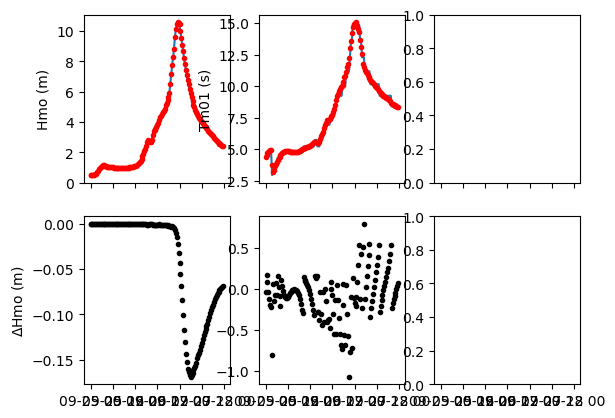

In [17]:
fig, axs = plt.subplots( 2, 3, sharex=True )

# Height
axs[0,0].plot( ds_spec['time'], ds_spec['Hm0'][:,320] )
axs[0,0].plot( ds_bulk['time'], ds_bulk['Hs_tp'][:,320],'.r')
axs[0,0].set_ylabel('Hmo (m)')
axs[1,0].plot( ds_spec['time'], ds_spec['Hm0'][:,320]- ds_bulk['Hs_tp'][:,320],'.k')
axs[1,0].set_ylabel('$\Delta$Hmo (m)')

# Period
axs[0,1].plot( ds_spec['time'], ds_spec['Tp'][:,320] )
axs[0,1].plot( ds_bulk['time'], ds_bulk['TPS_tp'][:,320],'.r')
axs[0,1].set_ylabel('Tp (s)')
axs[1,1].plot( ds_spec['time'], ds_spec['Tp'][:,320]- ds_bulk['TPS_tp'][:,320],'.k')
axs[1,1].set_ylabel('$\Delta$Tp (m)')

# Direction
axs[0,2].plot( ds_spec['time'], ds_spec['Tp'][:,320] )
axs[0,2].plot( ds_bulk['time'], ds_bulk['Dir_tp'][:,320],'.r')
axs[0,2].set_ylabel('Tp (s)')
axs[1,2].plot( ds_spec['time'], ds_spec['Tp'][:,320]- ds_bulk['TPS_tp'][:,320],'.k')
axs[1,2].set_ylabel('$\Delta$Tp (m)')

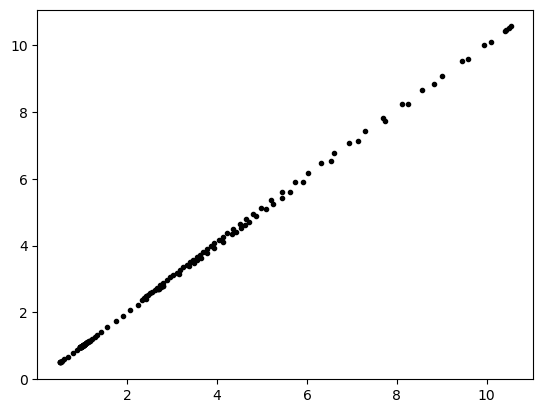

In [8]:
plt.plot( ds_spec['Hm0'][:,320], ds_bulk['Hs_tp'][:,320],'.k')

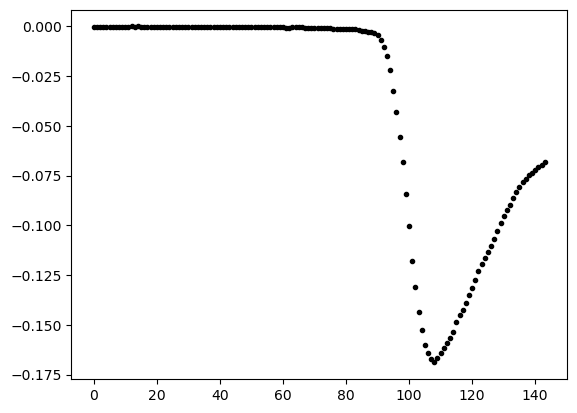

In [9]:
plt.plot( ds_spec['Hm0'][:,320]- ds_bulk['Hs_tp'][:,320],'.k')

Text(0, 0.5, 'Interpolated Depth (m)')

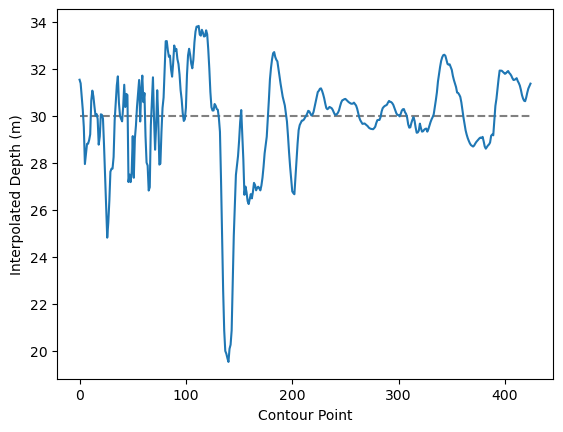

In [10]:
plt.plot( ds_tp['point'], 30.*np.ones_like( ds_tp['depth_p'] ),'--', c='gray')
plt.plot( ds_tp['point'], ds_tp['depth_p'] )
plt.xlabel('Contour Point')
plt.ylabel('Interpolated Depth (m)')